# 文件: chart_16_1.py

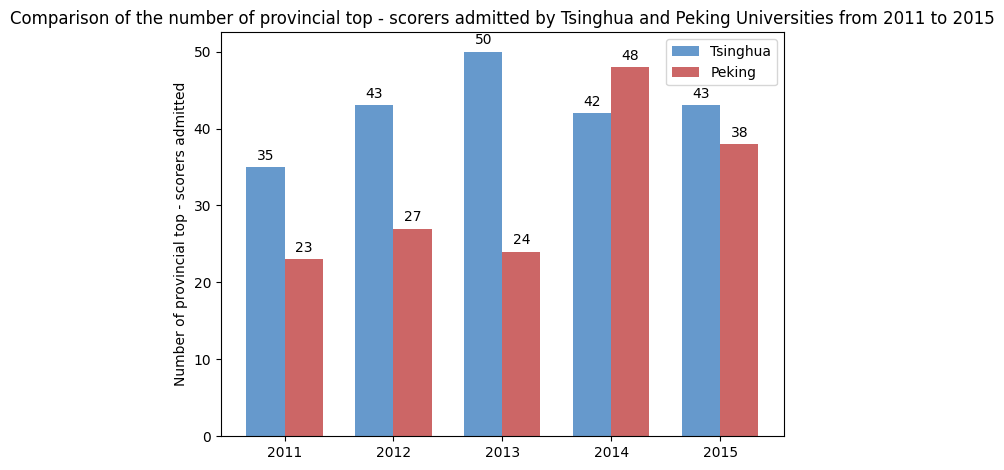

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = [2011, 2012, 2013, 2014, 2015]
# Number of provincial top - scorers admitted by Tsinghua University
qinghua = [35, 43, 50, 42, 43]
# Number of provincial top - scorers admitted by Peking University
beida = [23, 27, 24, 48, 38]

# Set the bar width
bar_width = 0.35
# Generate x - axis positions for the two groups of bars
x = np.arange(len(years))

# Create a figure and axes
fig, ax = plt.subplots()

# Draw the bars for Tsinghua University
rects1 = ax.bar(x - bar_width/2, qinghua, bar_width, label='Tsinghua', color='#6699CC')
# Draw the bars for Peking University
rects2 = ax.bar(x + bar_width/2, beida, bar_width, label='Peking', color='#CC6666')

# Set the x - axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(years)
# Set the y - axis label
ax.set_ylabel('Number of provincial top - scorers admitted')
# Set the title
ax.set_title('Comparison of the number of provincial top - scorers admitted by Tsinghua and Peking Universities from 2011 to 2015')
# Add a legend
ax.legend()

# Label the values on the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 - point vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# Adjust the layout to avoid label overlap
fig.tight_layout()
# Display the chart
plt.show()

# 文件: chart_16_2.py

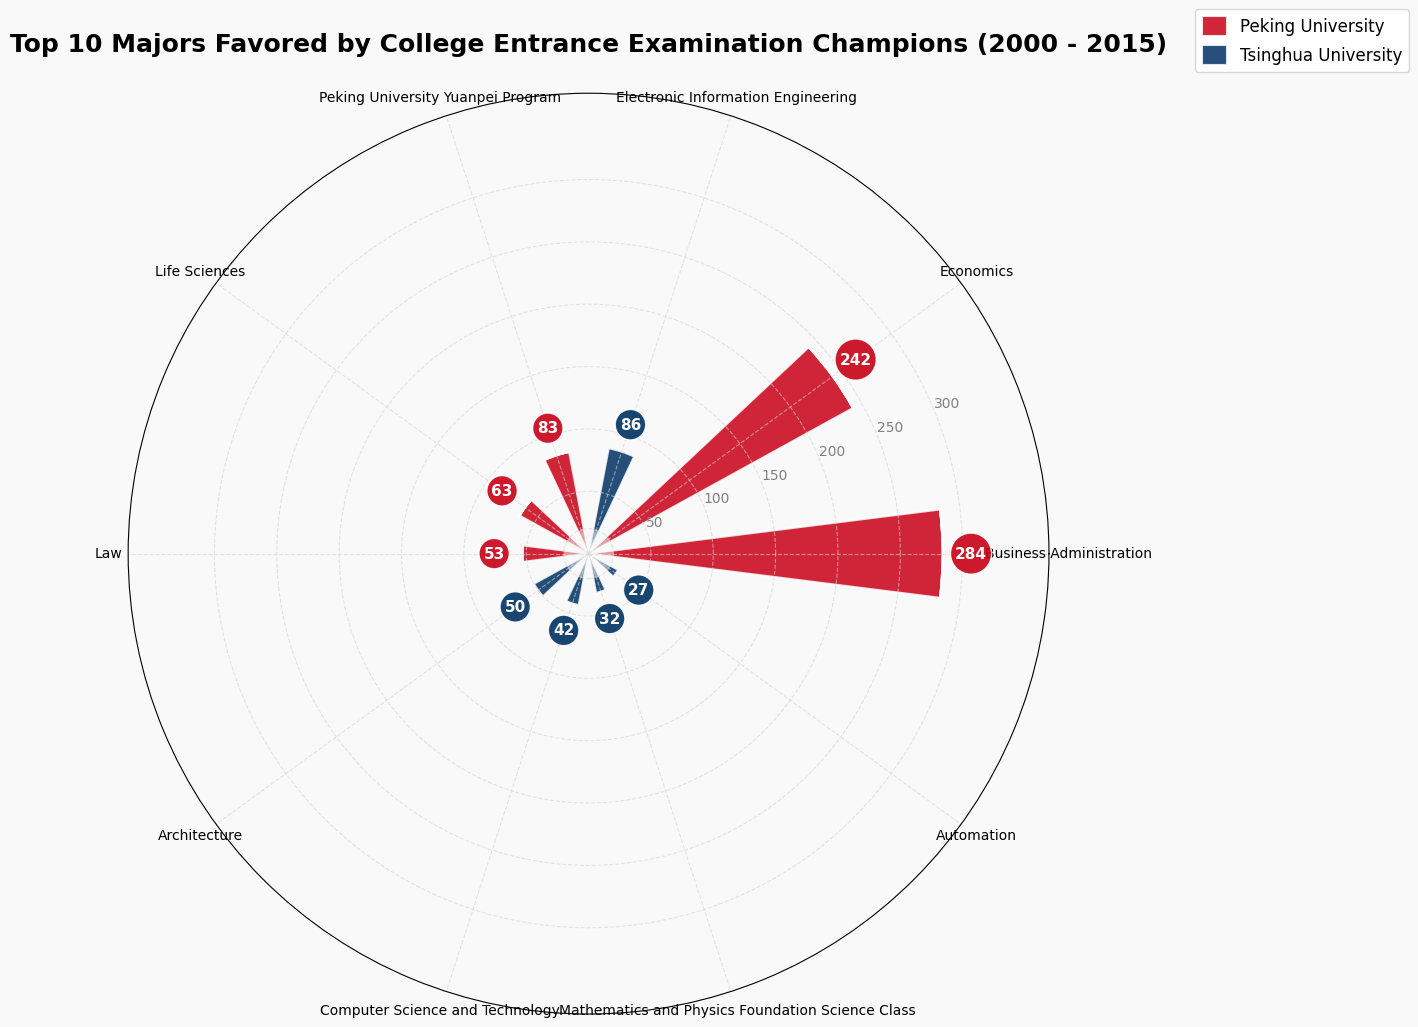

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from matplotlib.colors import LinearSegmentedColormap

# 专业名称列表
majors = [
    "Business Administration", "Economics", "Electronic Information Engineering", "Peking University Yuanpei Program",
    "Life Sciences", "Law", "Architecture", "Computer Science and Technology",
    "Mathematics and Physics Foundation Science Class", "Automation"
]
# 北京大学和清华大学的数据（按专业顺序排列）
data_pku = [284, 242, 0, 83, 63, 53, 0, 0, 0, 0]
data_tsinghua = [0, 0, 86, 0, 0, 0, 50, 42, 32, 27]

# 计算极坐标角度，每个专业对应一个角度
angles = np.linspace(0, 2 * np.pi, len(majors), endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

# 创建自定义配色方案
pku_color = '#C90016'  # 北京大学红色
th_color = '#003162'   # 清华大学蓝色
bg_color = '#F9F9F9'   # 背景色

# 创建画布和极坐标子图
fig = plt.figure(figsize=(14, 14), facecolor=bg_color)  # 增大画布尺寸
ax = plt.subplot(111, polar=True, facecolor=bg_color)

# 绘制北京大学的数据柱状图
bars_pku = ax.bar(
    angles[:-1], data_pku, width=0.25,
    color=pku_color, alpha=0.85,
    edgecolor='white', linewidth=1.5,
    label='Peking University'
)

# 绘制清华大学的数据柱状图
bars_tsinghua = ax.bar(
    angles[:-1], data_tsinghua, width=0.25,
    color=th_color, alpha=0.85,
    edgecolor='white', linewidth=1.5,
    bottom=data_pku, label='Tsinghua University'
)

# 设置网格线样式
ax.grid(True, color='lightgray', linestyle='--', alpha=0.6)

# 设置极坐标标签（专业名称）
ax.set_thetagrids(np.degrees(angles[:-1]), majors)
plt.setp(ax.get_xticklabels(), fontsize=10, weight='medium')  # 减小字体大小

# 设置径向刻度（隐藏默认刻度并自定义显示）
max_value = max([p + t for p, t in zip(data_pku, data_tsinghua)])
ax.set_ylim(0, max_value * 1.3)  # 增加上限，为标签留出更多空间
ax.set_rticks([50, 100, 150, 200, 250, 300])
plt.setp(ax.get_yticklabels(), fontsize=10, color='gray')

# 设置标题
plt.title("Top 10 Majors Favored by College Entrance Examination Champions (2000 - 2015)",
          fontsize=18, fontweight='bold', pad=30)

# 智能计算标签位置，避免重叠
label_positions = {}  # 存储每个角度的标签位置

for i, (angle, pku_val, th_val) in enumerate(zip(angles[:-1], data_pku, data_tsinghua)):
    total_height = pku_val + th_val
    
    # 计算基础偏移量
    base_offset = max_value * 0.08
    
    # 检查当前角度附近是否有其他标签
    conflict_angles = [a for a in label_positions.keys() 
                      if abs(a - angle) < 0.3 or abs(a - angle) > 2 * np.pi - 0.3]
    
    # 如果有冲突，增加偏移量
    if conflict_angles:
        max_offset = max(label_positions[a] for a in conflict_angles)
        offset = max_offset + base_offset * 1.5  # 增加更多间距
    else:
        offset = base_offset
    
    # Peking University label
    if pku_val > 0:
        label_r = pku_val + offset
        ax.annotate(
            f"{pku_val}",
            xy=(angle, pku_val),
            xytext=(angle, label_r),
            textcoords='data',
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="circle,pad=0.3", fc=pku_color, ec='white', alpha=0.9)
        )
        label_positions[angle] = label_r
    
    # Tsinghua University label
    if th_val > 0:
        label_r = total_height + offset
        ax.annotate(
            f"{th_val}",
            xy=(angle, total_height),
            xytext=(angle, label_r),
            textcoords='data',
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="circle,pad=0.3", fc=th_color, ec='white', alpha=0.9)
        )
        label_positions[angle] = label_r

# 自定义图例
legend = ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.4, 1.1),
    frameon=True,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=12,
    markerscale=1.2,
    handlelength=1.5,
    handleheight=1.5
)
frame = legend.get_frame()
frame.set_facecolor('white')

# 添加中心圆
center_circle = Circle((0, 0), 20, transform=ax.transData._b,
                       facecolor=bg_color, edgecolor='lightgray', linestyle='--', alpha=0.5)
ax.add_artist(center_circle)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# 显示图表
plt.show()